# Proyecto: Identificador de firmas falsas
## Integrantes:
- Martínez Marcelo Ingrid Aylen -
- Pérez Evaristo Eris
- Ramírez Venegas Alexa Paola

Para este proyecto utilizaremos el dataset "Signature_Verification" disponible en Kaggle con el objetivo de que nuestra red neuronal sea capaz de diferenciar entre firmas las cuales sean verdaderas y falsas. Los datos del dataset son datos no estructurados y para manejarlos se utilizará la arquitectura de red (añadir después o preguntar a Mijangos) con pytorch.
Este proyecto plantea en tratar de resolver la problemática de las falsificaciones de firmas en distintos documentos sensibles.

Información de redes siamesas:
https://medium.com/@rinkinag24/a-comprehensive-guide-to-siamese-neural-networks-3358658c0513

Información de redes triplet:


### Estructura del dataset
El dataset que elegimos para este proyecto cuenta con la siguiente estructura:
- ./train 
- ./test
test_data.csv
train_data.csv

En las carpetas de train y test se tienen las imagenes correspondientes a las firmas recolectadas por el dataset en formato *.png*, mientras que en los archivos .csv se tienen los datos correspondientes a las imágenes en donde se tienen las etiquetas correspondientes si es que estas son verdaderas o falsas.

# NOTAS
Para poder correr el proyecto es necesario activar el ambiente que viene incluido junto a este notebook. El cual es _*environment.yml*_

## Creación y activación del ambiente

Para poder ejecutar el ambiente tiene que ejecutarse el siguiente comando en la terminal a la altura del archivo del ambiente.
``` bash
conda env create -f environment.yml
```
Esto descargará las dependencias necesarias para poder ejecutar el proyecto. 

Para poder activarlo basta con escribir el siguiente comando en la terminal
``` bash
conda activate proyecto
```
O bien, si se está ejecutando desde un notebook o visual studio code basta con cambiar el kernel al kernel por nombre proyecto.

In [ ]:
#Imports que tal vez ocupemos, entre ellos me pareció mejor la opción de transformers
import torch
import torchvision
import torch.nn as nn #Capas de redes
import torchvision.transforms as transforms #transformers
import pandas as pd #visualización de los .csv
import numpy as np 
import tqdm as tqdm #Barras de progreso
import os #funciones del sistema operativo
import shutil #mover directorios, imagenes, etc
import kagglehub

from torch import optim #optimizadores
from torch.utils.data import DataLoader, Dataset, random_split
from pathlib import Path
from PIL import Image

In [5]:
# Download latest version ()
path = kagglehub.dataset_download("robinreni/signature-verification-dataset")
destino = os.path.join(os.getcwd(), "signature_dataset")
#movemos la carpeta a la par que todo lo demás
if not os.path.exists(destino):
    shutil.copytree(path, destino, dirs_exist_ok=True) #copiamos, esto para evitar descargas repetidas
    print("Directorio movido con éxito :)")
else:
    print("Directorio ya existente, no es necesario mover de nuevo :)")

Directorio ya existente, no es necesario mover de nuevo :)


Ruta de prueba; entrenamiento csv: /home/eris/CC/Septimo Semestre/Redes Neuronales/RedesNeuronales/Proyecto/signature_dataset/sign_data/train_data.csv
   068/09_068.png  068_forg/03_0113068.PNG  1
0  068/09_068.png  068_forg/01_0124068.PNG  1
1  068/09_068.png  068_forg/02_0124068.PNG  1
2  068/09_068.png  068_forg/01_0113068.PNG  1
3  068/09_068.png  068_forg/04_0124068.PNG  1
4  068/09_068.png  068_forg/04_0113068.PNG  1
   068/09_068.png  068_forg/03_0113068.PNG  1
0  068/09_068.png  068_forg/01_0124068.PNG  1
1  068/09_068.png  068_forg/02_0124068.PNG  1
2  068/09_068.png  068_forg/01_0113068.PNG  1
3  068/09_068.png  068_forg/04_0124068.PNG  1
4  068/09_068.png  068_forg/04_0113068.PNG  1


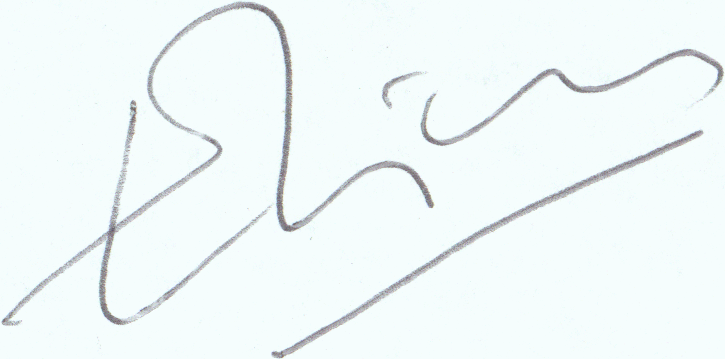

In [16]:
#Primero definimos las rutas que vamos a ocupar, el entrenamiento,test tanto para imagenes como para csv
# Path(__file__).resolve().parent obtiene la ruta absoluta del script que se ejecuta
# Path('data/sign_data') le añade la ruta relativa a los datos que vamos a estar usadno.

DIRECTORIO_BASE = Path(os.getcwd()) #Ruta de nuestro proyecto :)
RUTA_DATOS = DIRECTORIO_BASE / 'signature_dataset' / 'sign_data'

ruta_train_csv = RUTA_DATOS / 'train_data.csv'
ruta_test_csv = RUTA_DATOS / 'test_data.csv'

ruta_imagen_train = RUTA_DATOS / 'train/001/001_01.PNG'

print(f"Ruta de prueba; entrenamiento csv: {ruta_train_csv}")

#Esto es para verificar que en cualquier computadora todo esté a la misma altura y orden
df_test = pd.read_csv(ruta_test_csv).head()
df_train = pd.read_csv(ruta_train_csv).head()

img_train = Image.open(ruta_imagen_train)

print(df_test)
print(df_train)
img_train